In [ ]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn -q
import transformers
print("✅ Transformers version:", transformers.__version__)

✅ Transformers version: 5.0.0


In [ ]:
# ===================================================
# CELL 2A — Import all libraries
# ===================================================

# PyTorch — deep learning framework
import torch

# HuggingFace Transformers — DistilBERT model & tokenizer
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# HuggingFace Datasets — SST-2 dataset load
from datasets import load_dataset

# Scikit-learn — evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# ===================================================
# CELL 2B — Check GPU
# ===================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Using device: {device}")

if device.type == "cuda":
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU! Go to Runtime > Change runtime type > T4 GPU")

🖥️  Using device: cuda
✅ GPU detected: Tesla T4


In [ ]:

# ===================================================
# CELL 3 — Load SST-2 Dataset
# ===================================================

print("⏳ Loading SST-2 dataset...")
dataset = load_dataset("glue", "sst2")

# taking a small portion for efficieny

train_data = dataset["train"].shuffle(seed=42).select(range(2000))
val_data   = dataset["validation"].shuffle(seed=42).select(range(400))

print(f"✅ Dataset loaded!")
print(f"📊 Training samples   : {len(train_data)}")
print(f"📊 Validation samples : {len(val_data)}")
print(f"\n🔍 Sample entry:")
print(f"   Text  : {train_data[0]['sentence']}")
print(f"   Label : {train_data[0]['label']} ({'Positive' if train_data[0]['label'] == 1 else 'Negative'})")

⏳ Loading SST-2 dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

✅ Dataset loaded!
📊 Training samples   : 2000
📊 Validation samples : 400

🔍 Sample entry:
   Text  : klein , charming in comedies like american pie and dead-on in election , 
   Label : 1 (Positive)


In [ ]:
# ===================================================
# CELL 4 — Load DistilBERT Tokenizer
# ===================================================


print("⏳ Loading DistilBERT tokenizer...")

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

print("✅ Tokenizer loaded!")
print(f"\n🔍 Tokenization example:")

sample = "I love this movie!"
tokens = tokenizer(sample, return_tensors="pt")
print(f"   Original  : {sample}")
print(f"   Input IDs : {tokens['input_ids']}")
print(f"   Decoded   : {tokenizer.decode(tokens['input_ids'][0])}")

⏳ Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded!

🔍 Tokenization example:
   Original  : I love this movie!
   Input IDs : tensor([[ 101, 1045, 2293, 2023, 3185,  999,  102]])
   Decoded   : [CLS] i love this movie! [SEP]


In [ ]:
# ===================================================
# CELL 5 — Tokenize the Dataset
# ===================================================

#fine tune tokenizers

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

print("⏳ Tokenizing dataset...")

train_tokenized = train_data.map(tokenize_function, batched=True)
val_tokenized   = val_data.map(tokenize_function, batched=True)

# Model format fixed and rationalized
train_tokenized = train_tokenized.rename_column("label", "labels")
val_tokenized   = val_tokenized.rename_column("label", "labels")

# Only essential columns kept for need
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("✅ Tokenization complete!")
print(f"📊 Train tokenized size : {len(train_tokenized)}")
print(f"📊 Val tokenized size   : {len(val_tokenized)}")

⏳ Tokenizing dataset...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

✅ Tokenization complete!
📊 Train tokenized size : 2000
📊 Val tokenized size   : 400


In [ ]:
# ===================================================
# CELL 6 — Load DistilBERT Model
# ===================================================


print("⏳ Loading DistilBERT model...")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    attn_implementation='eager' # Set attention implementation to 'eager'
)

model = model.to(device)

# Model এর parameter count করা
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ Model loaded successfully!")
print(f"📊 Total parameters     : {total_params:,}")
print(f"📊 Trainable parameters : {trainable_params:,}")
print(f"🖥️  Model is on         : {next(model.parameters()).device}")

⏳ Loading DistilBERT model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded successfully!
📊 Total parameters     : 66,955,010
📊 Trainable parameters : 66,955,010
🖥️  Model is on         : cuda:0


In [ ]:
# ===================================================
# CELL 7 — Define Training Arguments
# ===================================================

# Rules for training


training_args = TrainingArguments(

    output_dir="./sentimentsense_model",  # save the model here

    # Train TIme
    num_train_epochs=3,              # go through all data 3 times
    per_device_train_batch_size=32,  # train 32 sentences at once
    per_device_eval_batch_size=64,   # check 64 sentences at once

    # Learn Criteria
    learning_rate=2e-5,   # small steps = stable learning
    weight_decay=0.01,    # prevents overfitting (memorizing data)

    # Accuracy Check
    eval_strategy="epoch",        # check accuracy after every epoch
    save_strategy="epoch",        # save model after every epoch
    load_best_model_at_end=True,  # keep the best version at the end
    metric_for_best_model="accuracy",

    # Log files
    logging_dir="./logs",   # save logs here
    logging_steps=50,       # show log every 50 steps
    report_to="none",       # turn off extra reporting

    fp16=True,  # faster training using GPU (uses less memory)
)

print("✅ Training arguments set!")
print(f"📊 Epochs          : {training_args.num_train_epochs}")
print(f"📊 Batch size      : {training_args.per_device_train_batch_size}")
print(f"📊 Learning rate   : {training_args.learning_rate}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Training arguments set!
📊 Epochs          : 3
📊 Batch size      : 32
📊 Learning rate   : 2e-05


In [ ]:
# ===================================================
# CELL 8 — Define Evaluation Metrics
# ===================================================

# This function checks how good our model is
# It runs automatically after every epoch

def compute_metrics(eval_pred):

    # get predictions and true labels
    logits, labels = eval_pred

    # pick the class with highest score (0 or 1)
    predictions = np.argmax(logits, axis=1)

    # accuracy = how many did we get right out of total
    acc = accuracy_score(labels, predictions)

    # precision = out of all predicted positive, how many were actually positive
    prec = precision_score(labels, predictions)

    # recall = out of all actual positive, how many did we catch
    rec = recall_score(labels, predictions)

    # f1 = balance between precision and recall (best single score)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy"  : round(acc,  4),
        "precision" : round(prec, 4),
        "recall"    : round(rec,  4),
        "f1"        : round(f1,   4),
    }

print("✅ Metrics function ready!")
print("📊 We will track: Accuracy, Precision, Recall, F1-Score")

✅ Metrics function ready!
📊 We will track: Accuracy, Precision, Recall, F1-Score


In [ ]:
# ===================================================
# CELL 9 — Build Trainer and Start Training
# ===================================================

# Trainer = HuggingFace er built-in training engine
# It handles everything automatically:
# forward pass, backward pass, optimization, evaluation

trainer = Trainer(
    model=model,                        # our DistilBERT model
    args=training_args,                 # rules we set in cell 7
    train_dataset=train_tokenized,      # training data
    eval_dataset=val_tokenized,         # validation data
    compute_metrics=compute_metrics,    # metrics function from cell 8
)

print("✅ Trainer is ready!")
print("🚀 Starting training now...")
print("⏳ This will take around 5-10 minutes on GPU...")
print("="*55)

# start training!
train_result = trainer.train()

print("="*55)
print("🎉 Training complete!")
print(f"⏱️  Total training time : {train_result.metrics['train_runtime']:.1f} seconds")
print(f"📊 Final training loss  : {train_result.metrics['train_loss']:.4f}")

✅ Trainer is ready!
🚀 Starting training now...
⏳ This will take around 5-10 minutes on GPU...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.571590,0.381865,0.835000,0.857100,0.824600,0.840600
2,0.327862,0.350168,0.850000,0.844700,0.876800,0.860500
3,0.252628,0.349548,0.852500,0.858500,0.862600,0.860500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


🎉 Training complete!
⏱️  Total training time : 39.6 seconds
📊 Final training loss  : 0.3466


In [ ]:
# ===================================================
# CELL 10 — Save Training History for Graphs
# ===================================================

# extract logs from trainer
logs = trainer.state.log_history

# separate train and eval logs
train_logs = [x for x in logs if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in logs if "eval_loss" in x]

# store values in lists
train_losses = [x["loss"] for x in train_logs]
eval_losses  = [x["eval_loss"] for x in eval_logs]
eval_acc     = [x["eval_accuracy"] for x in eval_logs]
eval_f1      = [x["eval_f1"] for x in eval_logs]
epochs       = list(range(1, len(eval_logs) + 1))

print("✅ Training history saved!")
print(f"📊 Epochs recorded : {epochs}")
print(f"📊 Eval Accuracy   : {[round(a*100, 2) for a in eval_acc]}")
print(f"📊 Eval F1 Score   : {[round(f, 4) for f in eval_f1]}")

✅ Training history saved!
📊 Epochs recorded : [1, 2, 3]
📊 Eval Accuracy   : [83.5, 85.0, 85.25]
📊 Eval F1 Score   : [0.8406, 0.8605, 0.8605]


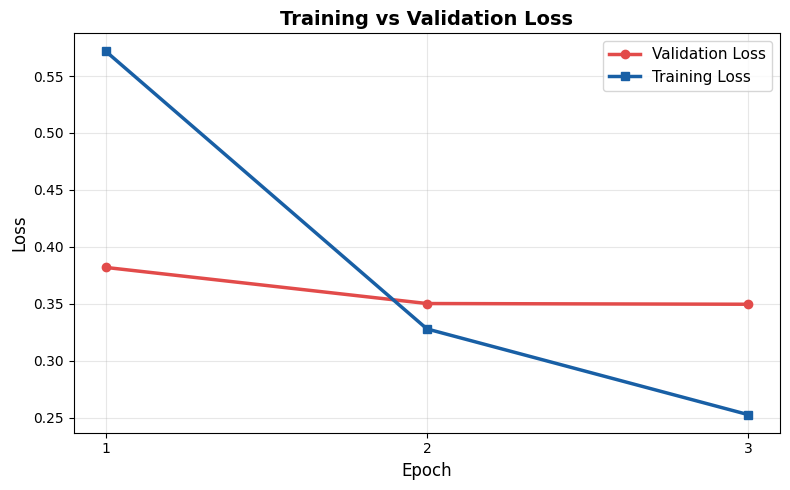

✅ Loss graph saved as loss_graph.png


In [ ]:
# ===================================================
# CELL 11 — Training vs Validation Loss Graph
# ===================================================

plt.figure(figsize=(8, 5))

plt.plot(epochs, eval_losses,
         marker='o', linewidth=2.5,
         color='#E24B4A', label='Validation Loss')

# approximate train loss per epoch (last value of each epoch)
train_loss_per_epoch = [train_losses[i] for i in
                        [len(train_losses)//3 - 1,
                         2*len(train_losses)//3 - 1,
                         len(train_losses) - 1]]

plt.plot(epochs, train_loss_per_epoch,
         marker='s', linewidth=2.5,
         color='#185FA5', label='Training Loss')

plt.title("Training vs Validation Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_graph.png", dpi=150)
plt.show()

print("✅ Loss graph saved as loss_graph.png")

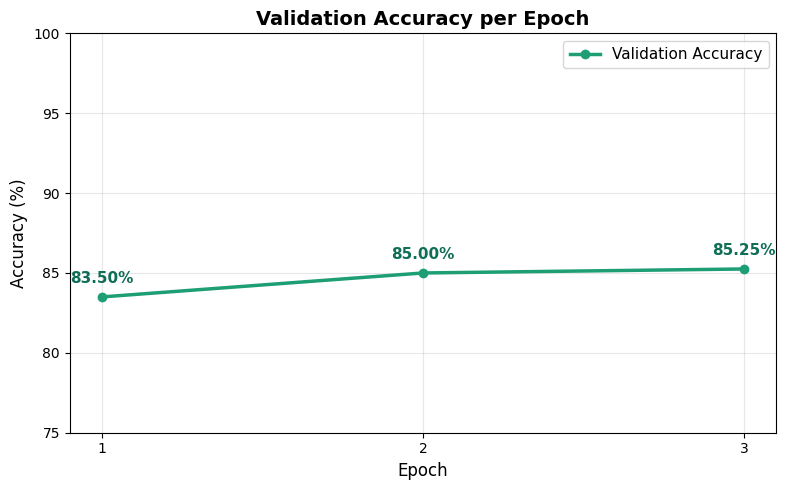

✅ Accuracy graph saved as accuracy_graph.png


In [ ]:
# ===================================================
# CELL 12 — Validation Accuracy Graph
# ===================================================

plt.figure(figsize=(8, 5))

plt.plot(epochs, [a * 100 for a in eval_acc],
         marker='o', linewidth=2.5,
         color='#1D9E75', label='Validation Accuracy')

# add value labels on each point
for i, acc in enumerate(eval_acc):
    plt.annotate(f'{acc*100:.2f}%',
                xy=(epochs[i], acc * 100),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=11,
                fontweight='bold', color='#0F6E56')

plt.title("Validation Accuracy per Epoch", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(epochs)
plt.ylim(75, 100)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_graph.png", dpi=150)
plt.show()

print("✅ Accuracy graph saved as accuracy_graph.png")

⏳ Getting predictions...


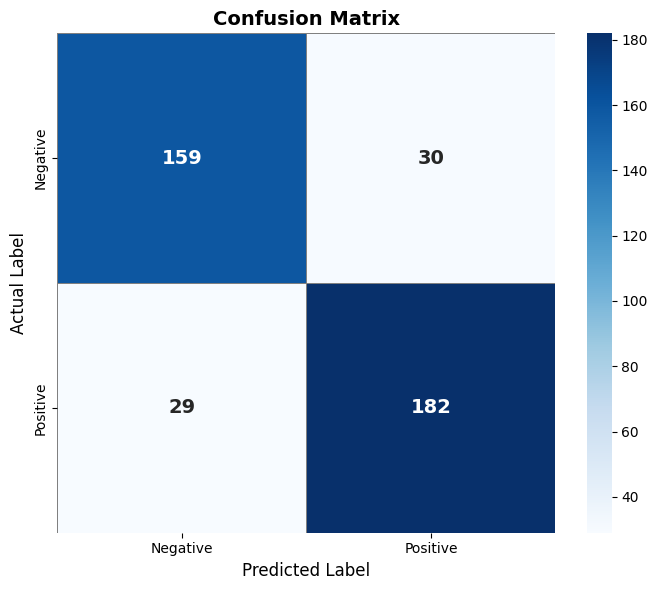


✅ Confusion Matrix saved!

📊 Results:
   True Positive  (TP) : 182  → Positive correctly identified
   True Negative  (TN) : 159  → Negative correctly identified
   False Positive (FP) : 30  → Negative wrongly called Positive
   False Negative (FN) : 29  → Positive wrongly called Negative


In [ ]:
# ===================================================
# CELL 13 — Confusion Matrix
# ===================================================


# first get predictions on validation set
print("⏳ Getting predictions...")
predictions = trainer.predict(val_tokenized)
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

# build confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, linecolor='gray',
            annot_kws={"size": 14, "weight": "bold"})

plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# explain the matrix
tn, fp, fn, tp = cm.ravel()
print(f"\n✅ Confusion Matrix saved!")
print(f"\n📊 Results:")
print(f"   True Positive  (TP) : {tp}  → Positive correctly identified")
print(f"   True Negative  (TN) : {tn}  → Negative correctly identified")
print(f"   False Positive (FP) : {fp}  → Negative wrongly called Positive")
print(f"   False Negative (FN) : {fn}  → Positive wrongly called Negative")

       📊 SENTIMENTSENSE AI — RESULTS
  ✅ Accuracy  : 85.25%
  ✅ Precision : 85.85%
  ✅ Recall    : 86.26%
  ✅ F1 Score  : 86.05%


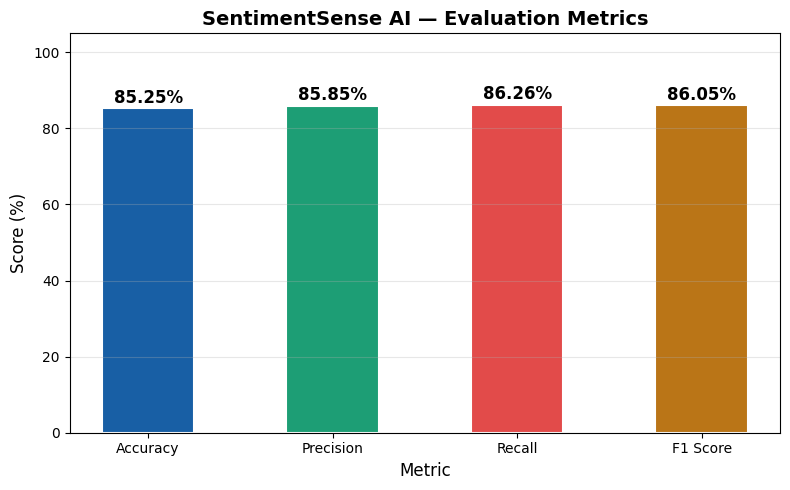

✅ Metrics bar chart saved as metrics_bar.png


In [ ]:
# ===================================================
# CELL 14 — Final Evaluation Metrics
# ===================================================

# calculate final metrics
acc  = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels)
rec  = recall_score(true_labels, pred_labels)
f1   = f1_score(true_labels, pred_labels)

# print clean results
print("=" * 45)
print("       📊 SENTIMENTSENSE AI — RESULTS")
print("=" * 45)
print(f"  ✅ Accuracy  : {acc*100:.2f}%")
print(f"  ✅ Precision : {prec*100:.2f}%")
print(f"  ✅ Recall    : {rec*100:.2f}%")
print(f"  ✅ F1 Score  : {f1*100:.2f}%")
print("=" * 45)

# plot metrics as bar chart
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [acc*100, prec*100, rec*100, f1*100]
colors         = ['#185FA5', '#1D9E75', '#E24B4A', '#BA7517']

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values,
               color=colors, width=0.5,
               edgecolor='white', linewidth=1.5)

# add value labels on top of each bar
for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.2f}%',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.title("SentimentSense AI — Evaluation Metrics",
          fontsize=14, fontweight='bold')
plt.xlabel("Metric", fontsize=12)
plt.ylabel("Score (%)", fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_bar.png", dpi=150)
plt.show()

print("✅ Metrics bar chart saved as metrics_bar.png")

/tmp/ipykernel_14495/3856667724.py:130: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14495/3856667724.py:131: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.savefig("predictions_viz.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


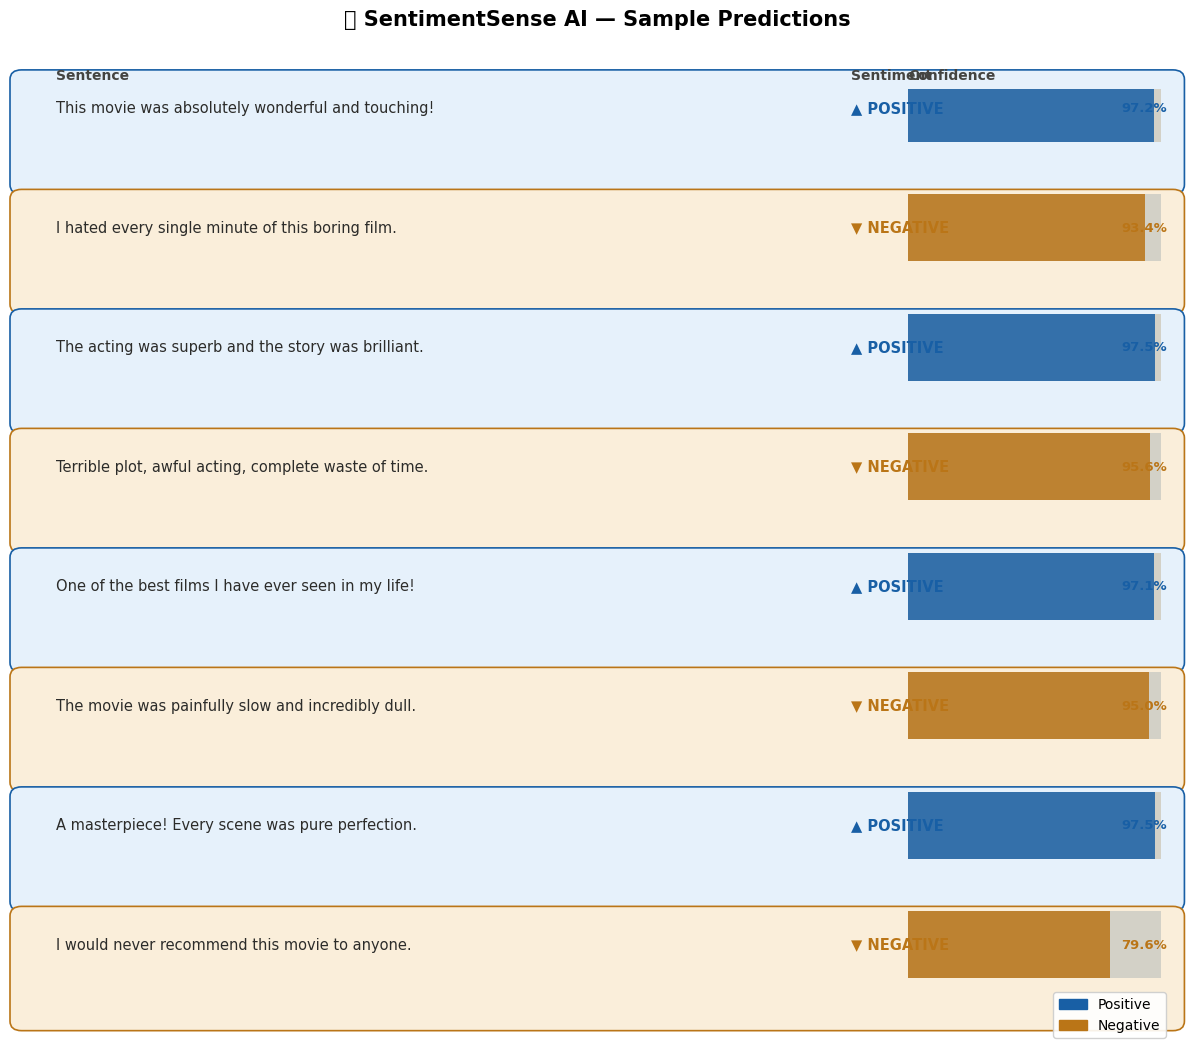

✅ Prediction visualization saved as predictions_viz.png


In [ ]:
# ===================================================
# CELL 15 — Sample Predictions with Visualization
# ===================================================

import matplotlib.patches as mpatches
import textwrap

test_sentences = [
    "This movie was absolutely wonderful and touching!",
    "I hated every single minute of this boring film.",
    "The acting was superb and the story was brilliant.",
    "Terrible plot, awful acting, complete waste of time.",
    "One of the best films I have ever seen in my life!",
    "The movie was painfully slow and incredibly dull.",
    "A masterpiece! Every scene was pure perfection.",
    "I would never recommend this movie to anyone.",
]

# ===================================================
# color settings
# ===================================================
POS_COLOR = "#185FA5"   # Blue   — Positive
NEG_COLOR = "#BA7517"   # Amber  — Negative
POS_BG    = "#E6F1FB"   # Light Blue background
NEG_BG    = "#FAEEDA"   # Light Amber background

# ===================================================
# get predictions
# ===================================================

model.eval()
results = []

for sentence in test_sentences:
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        max_length=128,
        truncation=True,
        padding="max_length"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs      = torch.softmax(outputs.logits, dim=1)
    confidence = probs.max().item() * 100
    pred       = torch.argmax(probs, dim=1).item()
    label      = "POSITIVE" if pred == 1 else "NEGATIVE"

    results.append({
        "sentence"   : sentence,
        "label"      : label,
        "confidence" : confidence,
        "color"      : POS_COLOR if label == "POSITIVE" else NEG_COLOR,
        "bg"         : POS_BG    if label == "POSITIVE" else NEG_BG,
        "icon"       : "▲" if label == "POSITIVE" else "▼"
    })

# ===================================================
# visualization
# ===================================================

fig, ax = plt.subplots(figsize=(12, len(results) * 1.3))
ax.axis('off')

fig.suptitle("🔮 SentimentSense AI — Sample Predictions",
             fontsize=15, fontweight='bold', y=1.01)

for i, r in enumerate(results):
    y = 1 - (i / len(results)) - 0.02

    # background row
    fancy_box = mpatches.FancyBboxPatch(
        (0, y - 0.08), 1, 0.11,
        boxstyle="round,pad=0.01",
        linewidth=1.2,
        edgecolor=r["color"],
        facecolor=r["bg"],
        transform=ax.transAxes,
        clip_on=False
    )
    ax.add_patch(fancy_box)

    # sentence text
    wrapped = textwrap.shorten(r["sentence"], width=65, placeholder="...")
    ax.text(0.03, y, wrapped,
            transform=ax.transAxes,
            fontsize=10.5, va='center',
            color='#2C2C2A')

    # label badge
    ax.text(0.72, y, f"{r['icon']} {r['label']}",
            transform=ax.transAxes,
            fontsize=10.5, va='center',
            fontweight='bold', color=r["color"])

    # confidence bar background
    ax.barh(y, 0.22, left=0.77, height=0.07,
            color='#D3D1C7', transform=ax.transAxes)

    # confidence bar fill
    ax.barh(y, 0.22 * (r["confidence"] / 100), left=0.77, height=0.07,
            color=r["color"], alpha=0.85, transform=ax.transAxes)

    # confidence text
    ax.text(0.995, y, f"{r['confidence']:.1f}%",
            transform=ax.transAxes,
            fontsize=9.5, va='center', ha='right',
            color=r["color"], fontweight='bold')

# column headers
ax.text(0.03, 1.01, "Sentence",
        transform=ax.transAxes, fontsize=10,
        fontweight='bold', color='#444441')
ax.text(0.72, 1.01, "Sentiment",
        transform=ax.transAxes, fontsize=10,
        fontweight='bold', color='#444441')
ax.text(0.77, 1.01, "Confidence",
        transform=ax.transAxes, fontsize=10,
        fontweight='bold', color='#444441')

# legend
pos_patch = mpatches.Patch(color=POS_COLOR, label='Positive')
neg_patch = mpatches.Patch(color=NEG_COLOR, label='Negative')
ax.legend(handles=[pos_patch, neg_patch],
          loc='lower right', fontsize=10,
          framealpha=0.9)

plt.tight_layout()
plt.savefig("predictions_viz.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Prediction visualization saved as predictions_viz.png")

In [ ]:
#Invoking XAI

In [ ]:
# install LIME and SHAP
!pip install lime shap -q

import lime
import lime.lime_text
import shap

print("✅ LIME and SHAP installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ LIME and SHAP installed!


⏳ Running LIME on: 'This movie was absolutely wonderful and touching!'
⏳ This may take 20-30 seconds...


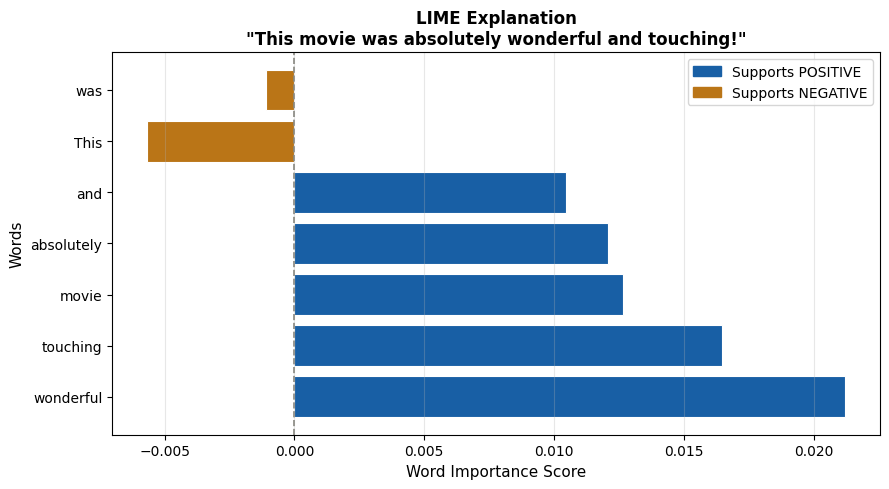


✅ LIME Explanation complete!
📝 Sentence   : This movie was absolutely wonderful and touching!
🏷️  Prediction : POSITIVE 😊
💯 Confidence : 97.21%

📊 Word Importance:
   wonderful       : +0.0212  → POSITIVE
   touching        : +0.0165  → POSITIVE
   movie           : +0.0127  → POSITIVE
   absolutely      : +0.0121  → POSITIVE
   and             : +0.0105  → POSITIVE
   This            : -0.0057  → NEGATIVE
   was             : -0.0011  → NEGATIVE


In [ ]:
# ===================================================
# CELL 16 — LIME (Local Interpretable Model-agnostic Explanations)
# ===================================================


from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import numpy as np


def predict_proba(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        max_length=128,
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()

# ===================================================
# setup LIME explainer
# ===================================================

explainer = LimeTextExplainer(class_names=["NEGATIVE", "POSITIVE"])

# sentence to explain
lime_sentence = "This movie was absolutely wonderful and touching!"

print(f"⏳ Running LIME on: '{lime_sentence}'")
print("⏳ This may take 20-30 seconds...")

# generate explanation
# num_samples = how many variations LIME tries
exp = explainer.explain_instance(
    lime_sentence,
    predict_proba,
    num_features=8,
    num_samples=500
)

# ===================================================
# visualization
# ===================================================

# get word importance scores
word_scores = exp.as_list()
words       = [w[0] for w in word_scores]
scores      = [w[1] for w in word_scores]
colors      = ["#185FA5" if s > 0 else "#BA7517" for s in scores]

plt.figure(figsize=(9, 5))
bars = plt.barh(words, scores, color=colors, edgecolor='white', linewidth=0.8)

plt.axvline(x=0, color='#888780', linewidth=1.2, linestyle='--')
plt.title(f'LIME Explanation\n"{lime_sentence}"',
          fontsize=12, fontweight='bold')
plt.xlabel("Word Importance Score", fontsize=11)
plt.ylabel("Words", fontsize=11)

# legend
pos_patch = mpatches.Patch(color='#185FA5', label='Supports POSITIVE')
neg_patch = mpatches.Patch(color='#BA7517', label='Supports NEGATIVE')
plt.legend(handles=[pos_patch, neg_patch], fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("lime_explanation.png", dpi=150)
plt.show()

# print prediction
pred_label = "POSITIVE 😊" if exp.predict_proba[1] > 0.5 else "NEGATIVE 😞"
print(f"\n✅ LIME Explanation complete!")
print(f"📝 Sentence   : {lime_sentence}")
print(f"🏷️  Prediction : {pred_label}")
print(f"💯 Confidence : {max(exp.predict_proba)*100:.2f}%")
print(f"\n📊 Word Importance:")
for word, score in word_scores:
    direction = "→ POSITIVE" if score > 0 else "→ NEGATIVE"
    print(f"   {word:15s} : {score:+.4f}  {direction}")

⏳ Setting up SHAP explainer...
⏳ This may take 30-60 seconds...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ SHAP values calculated!

📊 SHAP Explanation — Sentence 1 (POSITIVE):



📊 SHAP Explanation — Sentence 2 (NEGATIVE):


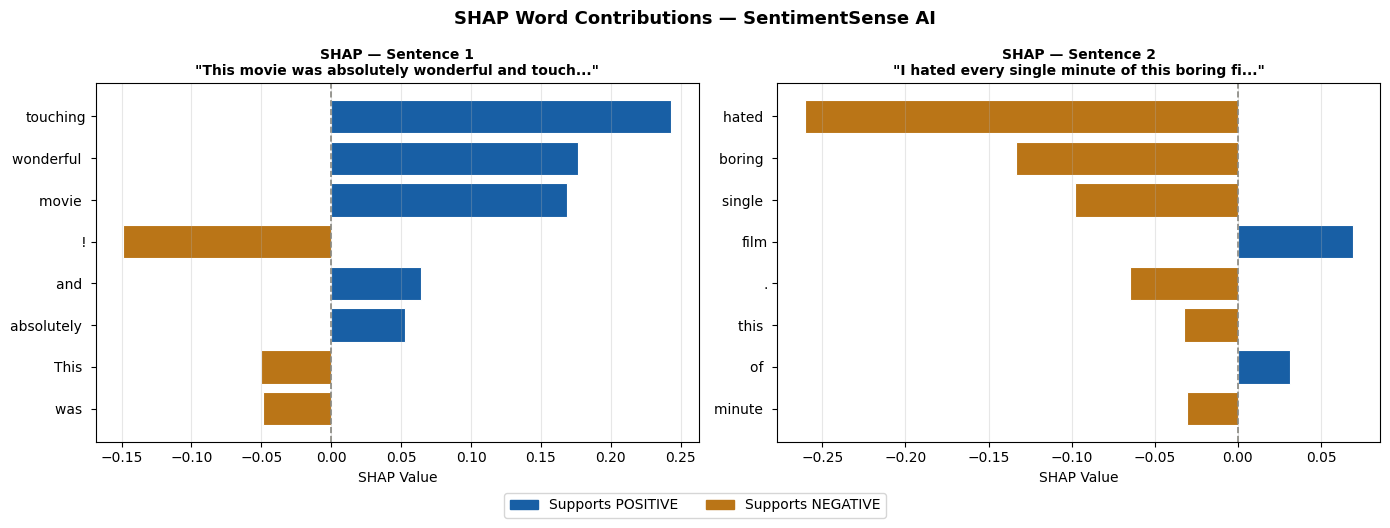


✅ SHAP Explanation complete!
📊 Blue bars  → word supports POSITIVE prediction
📊 Amber bars → word supports NEGATIVE prediction


In [ ]:
# ===================================================
# CELL 17 — SHAP (SHapley Additive exPlanations)
# ===================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# ===================================================
# SHAP Pipeline
# ===================================================

from transformers import pipeline

# sentiment pipeline বানাও
sentiment_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True
)

# ===================================================
# SHAP explainer setup
# ===================================================

# sentence to explain
shap_sentences = [
    "This movie was absolutely wonderful and touching!",
    "I hated every single minute of this boring film.",
]

print("⏳ Setting up SHAP explainer...")
print("⏳ This may take 30-60 seconds...")

# use SHAP's Partition explainer for text
explainer_shap = shap.Explainer(
    sentiment_pipeline,
    algorithm="partition",
    output_names=["NEGATIVE", "POSITIVE"]
)

# generate SHAP values
shap_values = explainer_shap(shap_sentences)

print("✅ SHAP values calculated!")

# ===================================================
# visualization — text plot
# ===================================================

print("\n📊 SHAP Explanation — Sentence 1 (POSITIVE):")
shap.plots.text(shap_values[0, :, "POSITIVE"])

print("\n📊 SHAP Explanation — Sentence 2 (NEGATIVE):")
shap.plots.text(shap_values[1, :, "NEGATIVE"])

# ===================================================
# bar plot — word contributions
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ax, sentence) in enumerate(zip(axes, shap_sentences)):

    sv     = shap_values[idx, :, 1]  # POSITIVE class
    tokens = sv.data
    values = sv.values

    # sort by absolute importance
    sorted_idx = np.argsort(np.abs(values))[-8:]
    top_tokens = [tokens[i] for i in sorted_idx]
    top_values = [values[i] for i in sorted_idx]
    colors     = ["#185FA5" if v > 0 else "#BA7517" for v in top_values]

    ax.barh(top_tokens, top_values,
            color=colors, edgecolor='white', linewidth=0.8)
    ax.axvline(x=0, color='#888780', linewidth=1.2, linestyle='--')
    ax.set_title(f'SHAP — Sentence {idx+1}\n"{sentence[:45]}..."',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel("SHAP Value", fontsize=10)
    ax.grid(axis='x', alpha=0.3)

# legend
pos_patch = mpatches.Patch(color='#185FA5', label='Supports POSITIVE')
neg_patch = mpatches.Patch(color='#BA7517', label='Supports NEGATIVE')
fig.legend(handles=[pos_patch, neg_patch],
           loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("SHAP Word Contributions — SentimentSense AI",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_explanation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ SHAP Explanation complete!")
print("📊 Blue bars  → word supports POSITIVE prediction")
print("📊 Amber bars → word supports NEGATIVE prediction")

In [ ]:
!pip install wordcloud -q
from wordcloud import WordCloud
print("✅ WordCloud installed!")

✅ WordCloud installed!


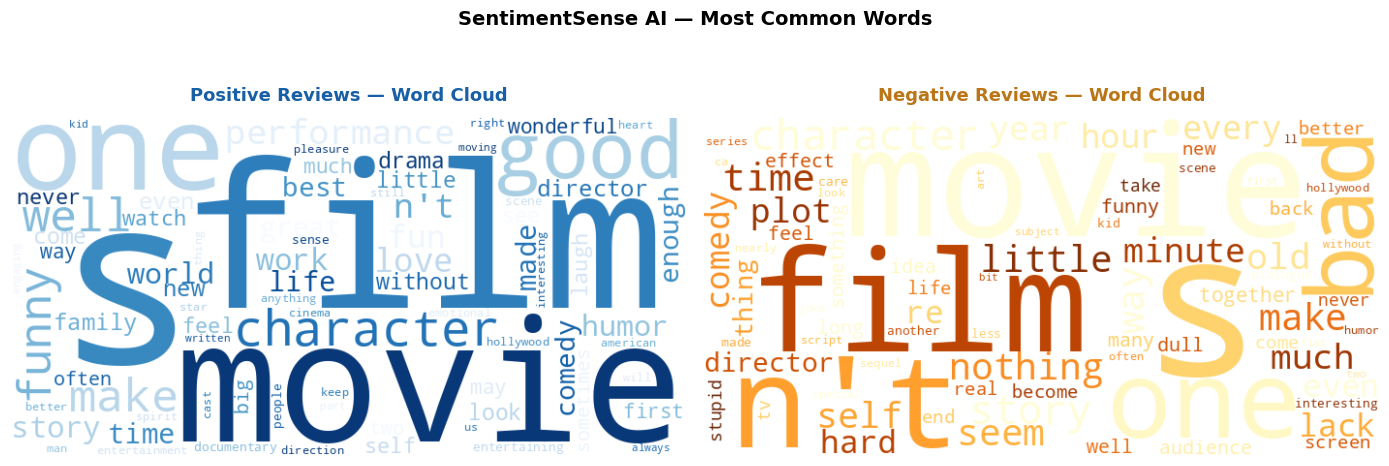

✅ Word Cloud saved as wordcloud.png


In [ ]:
# ===================================================
# CELL 18 — Word Cloud (Positive vs Negative)
# ===================================================


from wordcloud import WordCloud
import matplotlib.pyplot as plt

# separate positive and negative sentences
pos_texts = " ".join([
    train_data[i]["sentence"]
    for i in range(len(train_data))
    if train_data[i]["label"] == 1
])

neg_texts = " ".join([
    train_data[i]["sentence"]
    for i in range(len(train_data))
    if train_data[i]["label"] == 0
])

# ===================================================
# generate word clouds
# ===================================================

wc_pos = WordCloud(
    width=700, height=350,
    background_color="white",
    colormap="Blues",
    max_words=80,
    collocations=False
).generate(pos_texts)

wc_neg = WordCloud(
    width=700, height=350,
    background_color="white",
    colormap="YlOrBr",
    max_words=80,
    collocations=False
).generate(neg_texts)

# ===================================================
# plot side by side
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Reviews — Word Cloud",
                  fontsize=13, fontweight="bold", color="#185FA5", pad=12)

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Negative Reviews — Word Cloud",
                  fontsize=13, fontweight="bold", color="#BA7517", pad=12)

plt.suptitle("SentimentSense AI — Most Common Words",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Word Cloud saved as wordcloud.png")

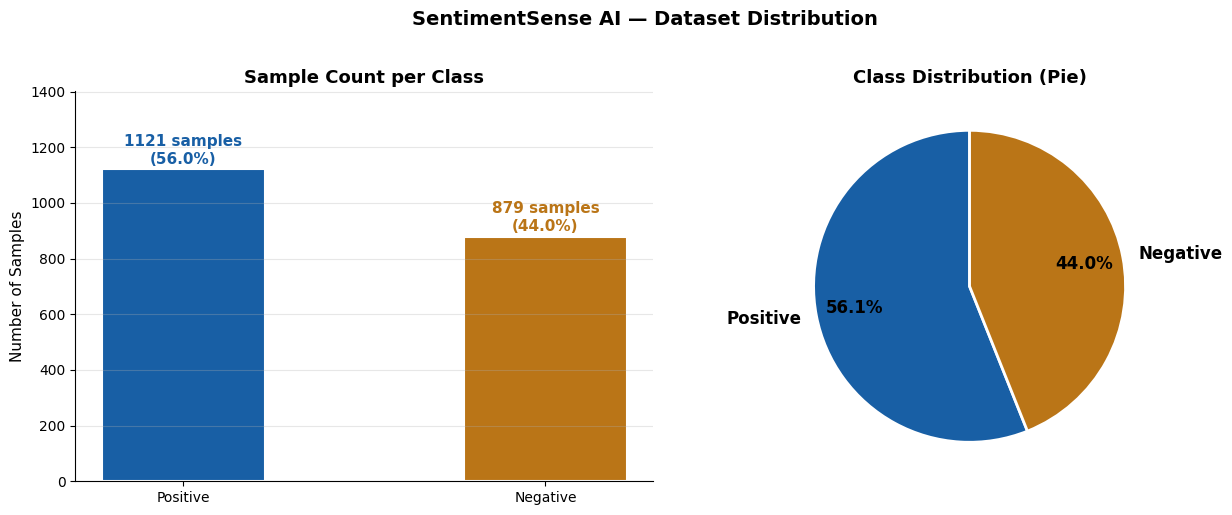

✅ Dataset Distribution chart saved!
📊 Positive samples : 1121 (56.0%)
📊 Negative samples : 879 (44.0%)


In [ ]:
# ===================================================
# CELL 19 — Dataset Distribution Chart
# ===================================================


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# count labels
pos_count  = sum(1 for i in range(len(train_data)) if train_data[i]["label"] == 1)
neg_count  = sum(1 for i in range(len(train_data)) if train_data[i]["label"] == 0)
total      = pos_count + neg_count
pos_pct    = pos_count / total * 100
neg_pct    = neg_count / total * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Bar Chart ---
bars = axes[0].bar(
    ["Positive", "Negative"],
    [pos_count, neg_count],
    color=["#185FA5", "#BA7517"],
    width=0.45,
    edgecolor="white",
    linewidth=1.5
)

# value labels on top of bars
for bar, count, pct in zip(bars, [pos_count, neg_count], [pos_pct, neg_pct]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count} samples\n({pct:.1f}%)",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color=bar.get_facecolor()
    )

axes[0].set_title("Sample Count per Class",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Samples", fontsize=11)
axes[0].set_ylim(0, max(pos_count, neg_count) * 1.25)
axes[0].grid(axis="y", alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# --- Pie Chart ---
axes[1].pie(
    [pos_count, neg_count],
    labels=["Positive", "Negative"],
    colors=["#185FA5", "#BA7517"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 12, "fontweight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[1].set_title("Class Distribution (Pie)",
                  fontsize=13, fontweight="bold")

plt.suptitle("SentimentSense AI — Dataset Distribution",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Dataset Distribution chart saved!")
print(f"📊 Positive samples : {pos_count} ({pos_pct:.1f}%)")
print(f"📊 Negative samples : {neg_count} ({neg_pct:.1f}%)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


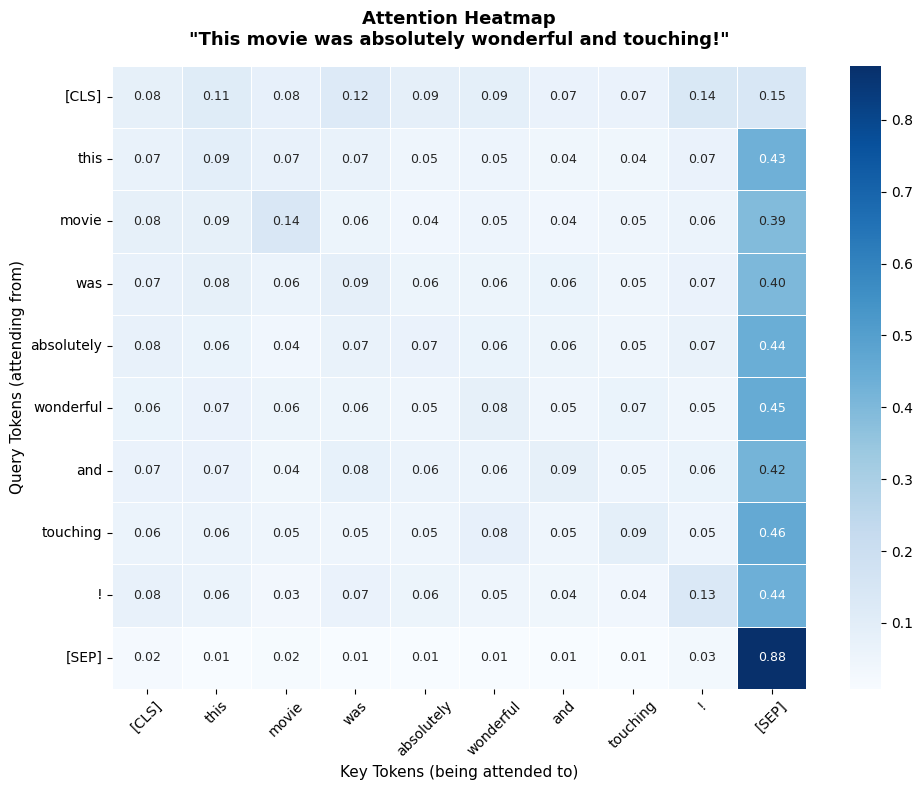

✅ Attention Heatmap saved!

📝 Sentence   : This movie was absolutely wonderful and touching!
🏷️  Prediction : POSITIVE 😊
💯 Confidence : 97.21%

💡 Darker cells = stronger attention between words


In [ ]:
# ===================================================
# CELL 20 — Attention Heatmap (Fixed)
# ===================================================

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import DistilBertForSequenceClassification

# sentence to analyze
attn_sentence = "This movie was absolutely wonderful and touching!"

# tokenize
inputs = tokenizer(
    attn_sentence,
    return_tensors="pt",
    max_length=128,
    truncation=True,
    padding=True
).to(device)

# ===================================================
# reload model with attention output enabled
# ===================================================

attn_model = DistilBertForSequenceClassification.from_pretrained(
    "./sentimentsense_model/checkpoint-best"
    if False else "distilbert-base-uncased",
    num_labels=2,
    output_attentions=True   # this enables attention weights
).to(device)

# copy trained weights into attn_model
attn_model.load_state_dict(model.state_dict())
attn_model.eval()

# get outputs with attention
with torch.no_grad():
    outputs = attn_model(**inputs)

# ===================================================
# extract attention weights
# ===================================================

attentions  = outputs.attentions         # tuple: one per layer
last_layer  = attentions[-1]             # last layer: (1, heads, seq, seq)
avg_attn    = last_layer[0].mean(dim=0) # average over heads
avg_attn    = avg_attn.cpu().numpy()

# get tokens
tokens   = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
real_len = (inputs["input_ids"][0] != tokenizer.pad_token_id).sum().item()
tokens   = tokens[:real_len]
avg_attn = avg_attn[:real_len, :real_len]

# clean token names
tokens = [t.replace("##", "") for t in tokens]

# ===================================================
# plot heatmap
# ===================================================

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    avg_attn,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9},
    ax=ax
)

ax.set_title(
    f'Attention Heatmap\n"{attn_sentence}"',
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Key Tokens (being attended to)", fontsize=11)
ax.set_ylabel("Query Tokens (attending from)", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("attention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# prediction
pred       = torch.argmax(outputs.logits, dim=1).item()
probs      = torch.softmax(outputs.logits, dim=1)
confidence = probs.max().item() * 100
label      = "POSITIVE 😊" if pred == 1 else "NEGATIVE 😞"

print("✅ Attention Heatmap saved!")
print(f"\n📝 Sentence   : {attn_sentence}")
print(f"🏷️  Prediction : {label}")
print(f"💯 Confidence : {confidence:.2f}%")
print(f"\n💡 Darker cells = stronger attention between words")

⏳ Calculating ROC curve...


/tmp/ipykernel_14495/3005297270.py:123: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14495/3005297270.py:124: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("roc_auc.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


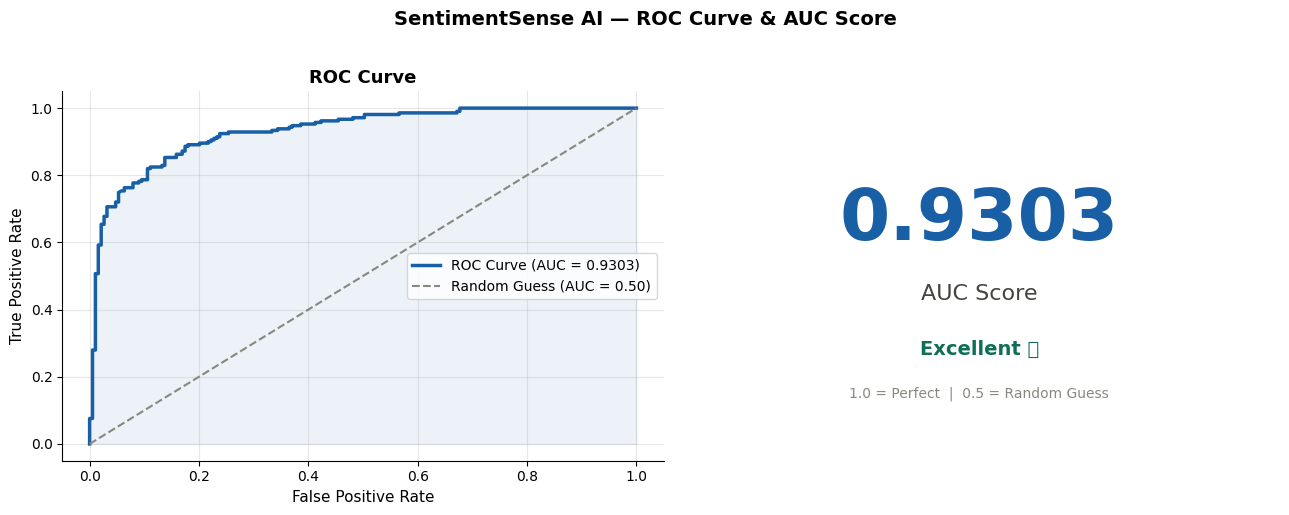

✅ ROC Curve saved as roc_auc.png

📊 AUC Score : 0.9303
📊 Result    : Excellent ✅


In [ ]:
# ===================================================
# CELL 21 — ROC Curve + AUC Score
# ===================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ===================================================
# get prediction probabilities
# ===================================================

print("⏳ Calculating ROC curve...")

# get all probabilities from validation set
all_probs  = []
all_labels = []

model.eval()

from torch.utils.data import DataLoader

val_loader = DataLoader(val_tokenized, batch_size=64)

for batch in val_loader:
    input_ids      = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels         = batch["labels"].cpu().numpy()

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    probs = torch.softmax(outputs.logits, dim=1)
    all_probs.extend(probs[:, 1].cpu().numpy())  # positive class prob
    all_labels.extend(labels)

# ===================================================
# calculate ROC curve
# ===================================================

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc              = auc(fpr, tpr)

# ===================================================
# plot
# ===================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC Curve ---
axes[0].plot(fpr, tpr,
             color="#185FA5", linewidth=2.5,
             label=f"ROC Curve (AUC = {roc_auc:.4f})")

# random guess line
axes[0].plot([0, 1], [0, 1],
             color="#888780", linewidth=1.5,
             linestyle="--", label="Random Guess (AUC = 0.50)")

# shade area under curve
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#185FA5")

axes[0].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

# --- AUC Score Card ---
axes[1].axis("off")

# big AUC number
axes[1].text(0.5, 0.65,
             f"{roc_auc:.4f}",
             ha="center", va="center",
             fontsize=52, fontweight="bold",
             color="#185FA5",
             transform=axes[1].transAxes)

axes[1].text(0.5, 0.45,
             "AUC Score",
             ha="center", va="center",
             fontsize=16, color="#444441",
             transform=axes[1].transAxes)

# performance label
if roc_auc >= 0.90:
    perf_label = "Excellent ✅"
    perf_color = "#0F6E56"
elif roc_auc >= 0.80:
    perf_label = "Good ✅"
    perf_color = "#185FA5"
else:
    perf_label = "Fair ⚠️"
    perf_color = "#BA7517"

axes[1].text(0.5, 0.30,
             perf_label,
             ha="center", va="center",
             fontsize=14, fontweight="bold",
             color=perf_color,
             transform=axes[1].transAxes)

axes[1].text(0.5, 0.18,
             "1.0 = Perfect  |  0.5 = Random Guess",
             ha="center", va="center",
             fontsize=10, color="#888780",
             transform=axes[1].transAxes)

# border around card
for spine in ["top", "bottom", "left", "right"]:
    axes[1].spines[spine].set_visible(True)
    axes[1].spines[spine].set_color("#D3D1C7")
    axes[1].spines[spine].set_linewidth(1)

plt.suptitle("SentimentSense AI — ROC Curve & AUC Score",
             fontsize=14, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("roc_auc.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ ROC Curve saved as roc_auc.png")
print(f"\n📊 AUC Score : {roc_auc:.4f}")
print(f"📊 Result    : {perf_label}")